<a href="https://colab.research.google.com/github/jpccmacedo-cmyk/CEP---MVP/blob/main/C%C3%B3pia_de_MVP_CEP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP - Controle Estatístico de Processo (CEP)
**Aluno:** João Pedro Cavalcante Castro Macedo  
**Matrícula:** 202029219  
**Disciplina:** CEP - Engenharia de Produção - UnB

**Professor:** Dr. Andre Luiz Marques Serrano

**Tema:** CEP na Agroindústria: Classificação Preditiva e Controle de Qualidade na Produção de Cafés Especiais.
**Dataset:** Coffee Quality Database (CQI) - Kaggle.

---

## 1. Definição do Problema

* **Objetivo:** Desenvolver um modelo preditivo de classificação capaz de antecipar se um lote de café atingirá o grau de "Café Especial" (nota global >= 80) com base em avaliações sensoriais intermediárias e atributos físicos do grão (umidade e número de defeitos).
* **Descrição do problema:** Na agroindústria do café, o valor de mercado flutua drasticamente. Lotes com pontuação global acima de 80 pontos na escala CQI são exportados como cafés especiais (alto valor). A aplicação do CEP preditivo permite que a cooperativa identifique lotes promissores precocemente e atue na correção de falhas de armazenagem (como excesso de umidade que gera defeitos).
* **Hipóteses:** Atributos como Acidez (Acidity) e Sabor (Flavor) terão alta correlação com a aprovação do lote, enquanto a presença de defeitos primários (Category One Defects) e alta umidade atuarão como ofensores da qualidade.
* **Dataset:** A base contém dados de mais de 1300 lotes de café Arábica, avaliados pelo Coffee Quality Institute. Utilizaremos atributos contínuos para prever uma classe binária.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Fixar seeds para reprodutibilidade (Boas Práticas)
SEED = 42
np.random.seed(SEED)

# Carga dos dados (Acessando o repositório raw no GitHub com a base limpa do Kaggle)
url = "https://raw.githubusercontent.com/jldbc/coffee-quality-database/master/data/arabica_data_cleaned.csv"
df = pd.read_csv(url)

# Selecionando apenas as colunas relevantes para o controle de processo e qualidade
features = ['Aroma', 'Flavor', 'Aftertaste', 'Acidity', 'Body', 'Balance',
            'Moisture', 'Category.One.Defects', 'Category.Two.Defects', 'Total.Cup.Points']

df = df[features]

# Exibir as primeiras linhas
display(df.head())
df.info()

,Aroma,Flavor,Aftertaste,Acidity,Body,Balance,Moisture,Category.One.Defects,Category.Two.Defects,Total.Cup.Points
0,8.67,8.83,8.67,8.75,8.50,8.42,0.12,0,0,90.58
1,8.75,8.67,8.50,8.58,8.42,8.42,0.12,0,1,89.92
2,8.42,8.50,8.42,8.42,8.33,8.42,0.00,0,0,89.75
3,8.17,8.58,8.42,8.42,8.50,8.25,0.11,0,2,89.00
4,8.25,8.50,8.25,8.50,8.42,8.33,0.12,0,2,88.83


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1311 entries, 0 to 1310
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Aroma                 1311 non-null   float64
 1   Flavor                1311 non-null   float64
 2   Aftertaste            1311 non-null   float64
 3   Acidity               1311 non-null   float64
 4   Body                  1311 non-null   float64
 5   Balance               1311 non-null   float64
 6   Moisture              1311 non-null   float64
 7   Category.One.Defects  1311 non-null   int64  
 8   Category.Two.Defects  1311 non-null   int64  
 9   Total.Cup.Points      1311 non-null   float64
dtypes: float64(8), int64(2)
memory usage: 102.6 KB


## 2. Preparação de Dados

* **Limpeza:** A base possui alguns valores nulos (NaNs) e outliers extremos em umidade. Faremos a remoção das linhas com dados faltantes para garantir a integridade do modelo.
* **Engenharia da Variável Alvo:** A coluna original `Total.Cup.Points` é contínua. Nós a transformaremos em uma variável binária `Specialty` para facilitar a decisão operacional: 1 (Aprovado como Especial, $\ge 80$) e 0 (Rebaixado para Comercial, $< 80$).
* **Divisão e Padronização:** Separaremos 80% dos lotes para treino e 20% para teste, usando `stratify` para balancear a proporção de cafés especiais e comerciais. Aplicaremos o `StandardScaler` apenas no conjunto de treino para evitar vazamento de dados.

In [3]:
# 1. Tratamento de Dados e Limpeza
df = df.dropna()

# Binarização da variável alvo (Regra de negócio do mercado de café)
df['Specialty_bin'] = df['Total.Cup.Points'].apply(lambda x: 1 if x >= 80 else 0)

# Verificando a distribuição das classes
print("Distribuição da Qualidade no Dataset:")
print(df['Specialty_bin'].value_counts())

# Separação de features (X) e target (y)
X = df.drop(['Total.Cup.Points', 'Specialty_bin'], axis=1)
y = df['Specialty_bin']

# Divisão entre treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

# Padronização (Ajuste exclusivo no treino)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nLotes para Treino: {X_train.shape[0]}")
print(f"Lotes para Teste: {X_test.shape[0]}")

Distribuição da Qualidade no Dataset:
Specialty_bin
1    1130
0     181
Name: count, dtype: int64

Lotes para Treino: 1048
Lotes para Teste: 263


## 3. Modelagem e Treinamento

* **Seleção de Algoritmos:** A **Regressão Logística** foi escolhida para servir como modelo baseline devido à sua alta explicabilidade, permitindo entender o impacto direto de cada atributo químico e sensorial através de seus coeficientes. Adicionalmente, optou-se pela utilização de métodos avançados na forma de comitês de modelos (*ensembles*): o **Random Forest** (baseado em *Bagging*) e o **XGBoost** (baseado em *Gradient Boosting*), capazes de mapear interações não-lineares complexas comuns na agroindústria.
* **Otimização de Hiperparâmetros:** Utilizaremos o `GridSearchCV` nos algoritmos de comitê para varrer uma grade de parâmetros essenciais (como profundidade das árvores e taxas de aprendizado), aplicando validação cruzada em 5 folds (CV=5) para mitigar o risco de *overfitting* e garantir a robustez estatística dos modelos.

In [4]:
import time
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

print("--- Treinando os Modelos ---")

# 1. Regressão Logística (Baseline)
print("\n[1/3] Treinando Regressão Logística (Baseline)...")
lr_model = LogisticRegression(random_state=SEED, max_iter=1000)
t0_lr = time.time()
lr_model.fit(X_train_scaled, y_train)
t_lr = time.time() - t0_lr
print(f"Tempo de Treinamento (LR): {t_lr:.2f}s")

# 2. Random Forest (Ensemble - Bagging) com GridSearchCV
print("\n[2/3] Treinando e Otimizando Random Forest...")
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}
rf = RandomForestClassifier(random_state=SEED)
t0_rf = time.time()
grid_rf = GridSearchCV(estimator=rf, param_grid=param_grid_rf, cv=5, scoring='accuracy', n_jobs=-1)
grid_rf.fit(X_train_scaled, y_train)
best_rf = grid_rf.best_estimator_
t_rf = time.time() - t0_rf
print(f"Tempo de Treinamento (RF): {t_rf:.2f}s")
print(f"Melhores parâmetros RF: {grid_rf.best_params_}")

# 3. XGBoost (Ensemble - Gradient Boosting) com GridSearchCV
print("\n[3/3] Treinando e Otimizando XGBoost...")
param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1]
}
xgb_model = XGBClassifier(random_state=SEED, eval_metric='logloss')
t0_xgb = time.time()
grid_xgb = GridSearchCV(estimator=xgb_model, param_grid=param_grid_xgb, cv=5, scoring='accuracy', n_jobs=-1)
grid_xgb.fit(X_train_scaled, y_train)
best_xgb = grid_xgb.best_estimator_
t_xgb = time.time() - t0_xgb
print(f"Tempo de Treinamento (XGB): {t_xgb:.2f}s")
print(f"Melhores parâmetros XGB: {grid_xgb.best_params_}")

--- Treinando os Modelos ---

[1/3] Treinando Regressão Logística (Baseline)...
Tempo de Treinamento (LR): 0.09s

[2/3] Treinando e Otimizando Random Forest...
Tempo de Treinamento (RF): 34.84s
Melhores parâmetros RF: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100}

[3/3] Treinando e Otimizando XGBoost...
Tempo de Treinamento (XGB): 2.53s
Melhores parâmetros XGB: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 200}


## 4. Avaliação de Resultados

* **Métricas Gerais:** Analisaremos de forma comparativa a Acurácia, Precisão, Recall e F1-Score obtidos na base de teste para cada um dos 3 modelos. No contexto de CEP e classificação de lotes, o foco estratégico está em equilibrar uma alta Precisão (evitar falsos positivos: lotes comerciais classificados como especiais que gerariam multas e quebra de contratos de exportação) com um bom Recall (garantir que bons lotes não sejam desperdiçados).
* **Análise de Variáveis:** Avaliaremos o impacto dos atributos sob três perspectivas diferentes: os coeficientes absolutos da Regressão Logística e a importância de recursos por ganho de informação pura nas árvores (Random Forest e XGBoost), identificando os principais direcionadores de qualidade.


 RELATÓRIO DE DESEMPENHO: REGRESSÃO LOGÍSTICA 
                 precision    recall  f1-score   support

Comercial (<80)       0.84      0.75      0.79        36
Especial (>=80)       0.96      0.98      0.97       227

       accuracy                           0.95       263
      macro avg       0.90      0.86      0.88       263
   weighted avg       0.94      0.95      0.95       263


 RELATÓRIO DE DESEMPENHO: RANDOM FOREST 
                 precision    recall  f1-score   support

Comercial (<80)       0.93      0.72      0.81        36
Especial (>=80)       0.96      0.99      0.97       227

       accuracy                           0.95       263
      macro avg       0.94      0.86      0.89       263
   weighted avg       0.95      0.95      0.95       263


 RELATÓRIO DE DESEMPENHO: XGBOOST 
                 precision    recall  f1-score   support

Comercial (<80)       0.89      0.67      0.76        36
Especial (>=80)       0.95      0.99      0.97       227

       accu

,Acurácia,Precisão,Recall,F1-Score
Regressão Logística,0.946768,0.961039,0.977974,0.969432
Random Forest,0.954373,0.957447,0.991189,0.974026
XGBoost,0.942966,0.949153,0.986784,0.967603



############################################################
 VEREDITO DO MVP: O MELHOR ALGORITMO FOI O: RANDOM FOREST 
 Critério de seleção: Maior Acurácia (0.9544) 
############################################################

O objeto 'melhor_modelo' foi definido e está pronto para produção/inferência.


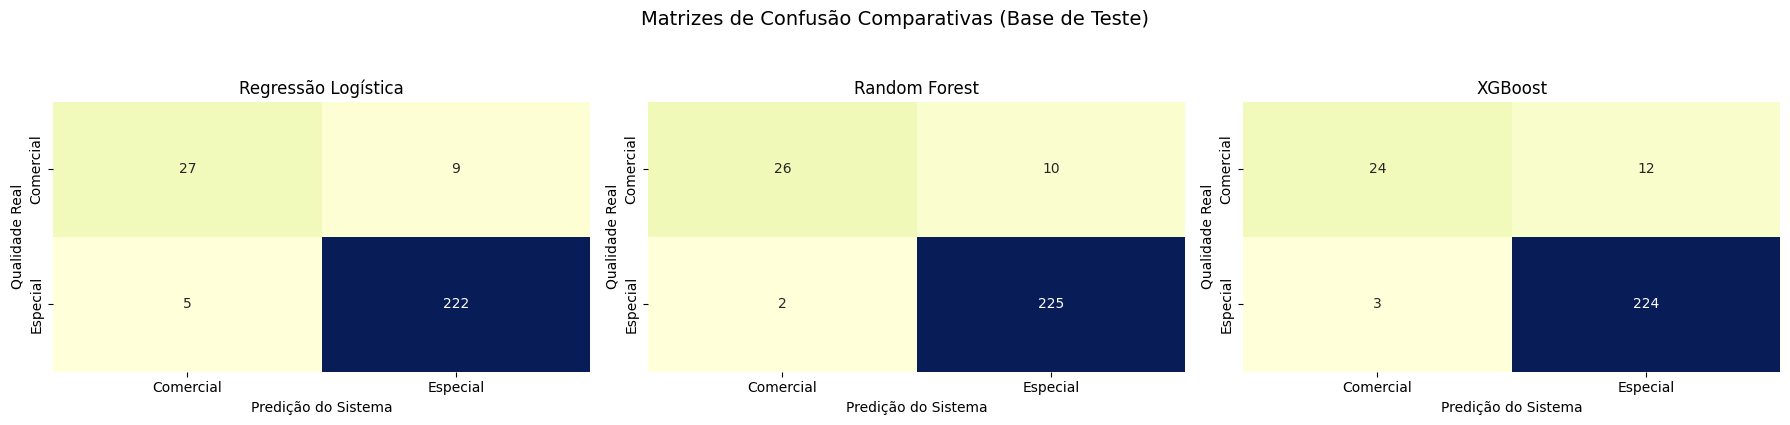

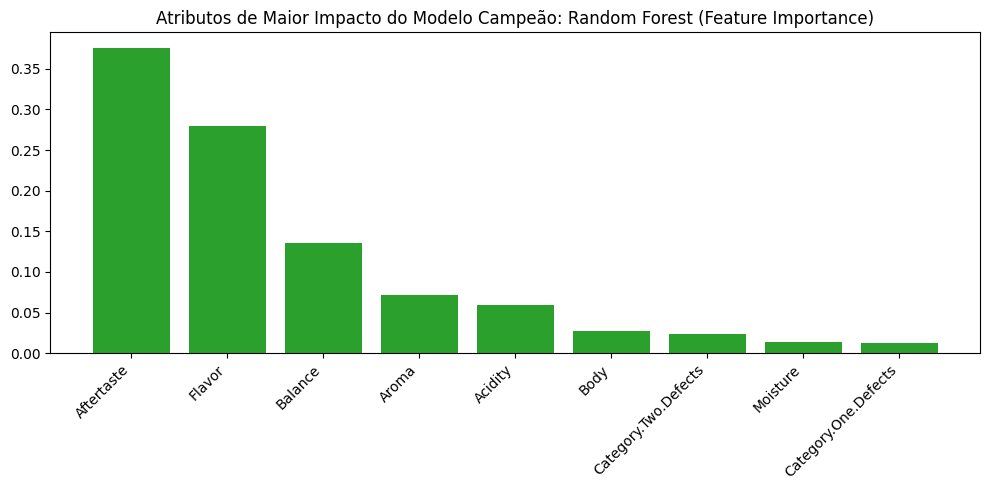

In [6]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Dicionário para armazenar as métricas de teste
results = {}

models = {
    'Regressão Logística': lr_model,
    'Random Forest': best_rf,
    'XGBoost': best_xgb
}

# 1. Avaliação individual e armazenamento das métricas
for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results[name] = {
        'Acurácia': acc,
        'Precisão': prec,
        'Recall': rec,
        'F1-Score': f1,
        'objeto_modelo': model # Guarda a referência do modelo treinado
    }

    print("\n" + "="*55)
    print(f" RELATÓRIO DE DESEMPENHO: {name.upper()} ")
    print("="*55)
    print(classification_report(y_test, y_pred, target_names=['Comercial (<80)', 'Especial (>=80)']))

# 2. Criar DataFrame comparativo para exibição (removendo a coluna do objeto de modelo)
df_perf = pd.DataFrame(results).T.drop(columns=['objeto_modelo'])
print("\n" + "="*55)
print(" TABELA COMPARATIVA DE DESEMPENHO (BASE DE TESTE) ")
print("="*55)
display(df_perf.round(4))

# 3. SELEÇÃO AUTOMÁTICA DO MELHOR MODELO (Critério: Maior Acurácia)
# Se quiser mudar o critério para 'F1-Score' ou 'Precisão', basta alterar a string abaixo:
criterio_selecao = 'Acurácia'

nome_melhor_modelo = max(results, key=lambda k: results[k][criterio_selecao])
melhor_modelo = results[nome_melhor_modelo]['objeto_modelo']
melhor_acuracia = results[nome_melhor_modelo][criterio_selecao]

print("\n" + "#"*60)
print(f" VEREDITO DO MVP: O MELHOR ALGORITMO FOI O: {nome_melhor_modelo.upper()} ")
print(f" Critério de seleção: Maior {criterio_selecao} ({melhor_acuracia:.4f}) ")
print("#"*60)
print("\nO objeto 'melhor_modelo' foi definido e está pronto para produção/inferência.")

# ==============================================================================
# VISUALIZAÇÕES GRÁFICAS (Matrizes de Confusão Lado a Lado)
# ==============================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', ax=ax, cbar=False,
                xticklabels=['Comercial', 'Especial'], yticklabels=['Comercial', 'Especial'])
    ax.set_title(f'{name}')
    ax.set_ylabel('Qualidade Real')
    ax.set_xlabel('Predição do Sistema')
plt.suptitle('Matrizes de Confusão Comparativas (Base de Teste)', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

# Gráfico de importância dos atributos para o campeão
plt.figure(figsize=(10, 5))
if nome_melhor_modelo == 'Regressão Logística':
    importances = np.abs(melhor_modelo.coef_[0])
    title_prefix = "Regressão Logística (Módulo dos Coeficientes)"
else:
    importances = melhor_modelo.feature_importances_
    title_prefix = f"{nome_melhor_modelo} (Feature Importance)"

indices = np.argsort(importances)[::-1]
plt.bar(range(X.shape[1]), importances[indices], color='#2ca02c')
plt.xticks(range(X.shape[1]), [X.columns[i] for i in indices], rotation=45, ha='right')
plt.title(f"Atributos de Maior Impacto do Modelo Campeão: {title_prefix}")
plt.tight_layout()
plt.show()